# Notebook 2 — Exploratory Data Analysis & Feature Analysis

**Goal:** Understand the structure and distributions of the RASFF dataset, quantify
feature–target associations, and justify the feature engineering choices made in NB3.

## EDA Workflow

| Section | Topic | Purpose |
|---------|-------|---------|
| 0 | Setup | Imports, shared utilities, data load |
| 1 | Target Variable | Understand `risk_decision` distributions and class balance |
| 2 | Feature–Target Association | Cramér's V for all features → feature priority ranking |
| 3 | Hazard Analysis | Explore `hazards`, `hazard_tag`, `hazard_substance`, `hazards_missing` |
| 4 | Food Category & Type | Category and type distributions vs risk |
| 5 | Geographic Analysis | Origin and notifying country vs risk |
| 6 | Temporal Trends | Year and month patterns |
| 7 | Key Findings & Feature Selection | Summary table for NB3 |

> **Design principle:** EDA proceeds target-first → association ranking → feature deep-dives.
> All Cramér's V scores computed here drive the encoding strategy in NB3.

---
## 0. Setup

In [ ]:
# ── Path Configuration ────────────────────────────────────────────
from pathlib import Path

# Resolves to rasff_risk_predictor/ root regardless of OS or user
ROOT_DIR  = Path.cwd().parent          # notebooks/ → rasff_risk_predictor/
DATA_DIR  = ROOT_DIR / "data"
MODEL_DIR = ROOT_DIR / "models"

# Verify folder structure on first run
for d in [DATA_DIR, MODEL_DIR]:
    if not d.exists():
        raise FileNotFoundError(
            f"Expected folder not found: {d}\n"
            "Please check your folder structure matches the README."
        )
# ──────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# ── Shared utility: Cramér's V (defined once, used throughout) ────────────────
def cramers_v(x, y):
    """Bias-corrected Cramér's V for association between two categorical series."""
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    phi2c = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rc = r - ((r-1)**2)/(n-1)
    kc = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2c / min(kc-1, rc-1))

# ── Load data ─────────────────────────────────────────────────────────────────
DATA_PATH = DATA_DIR / "rasff_clean2.csv"  # [MODIFIED] 원래 코드: DATA_PATH = 'rasff_clean2.csv'
df = pd.read_csv(DATA_PATH, on_bad_lines='skip')
df['date'] = pd.to_datetime(df['date'])

# ── Reconstruct NB1 features if not present ──────────────────────────────────
def extract_primary_tag(h):
    if pd.isnull(h): return 'unknown'
    tags = re.findall(r'\{([^}]+)\}', str(h))
    return tags[0].strip() if tags else 'unknown'

def extract_primary_substance(h):
    if pd.isnull(h): return 'unknown'
    parts = str(h).split(',')
    m = re.match(r'^(.+?)\s+-\s+\{', parts[0].strip())
    if m:
        s = m.group(1).strip().lower()
        s = re.sub(r'\s+(unauthorised substance|high level|migration|too high content'
                   r'|illegal trade.*|susp.*)', '', s).strip()
        return s
    return parts[0].strip().lower()[:80] if parts[0].strip() else 'unknown'

if 'hazard_tag' not in df.columns:
    df['hazard_tag']       = df['hazards'].apply(extract_primary_tag)
    df['hazard_substance'] = df['hazards'].apply(extract_primary_substance)
    df['hazards_missing']  = df['hazards'].isnull().astype(int)

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')


Shape: (29984, 20)
Columns: ['reference', 'category', 'type', 'subject', 'date', 'notifying_country', 'classification', 'risk_decision', 'distribution', 'forAttention', 'forFollowUp', 'operator', 'origin', 'hazards', 'year', 'month', 'Hazard_Type', 'hazard_tag', 'hazard_substance', 'hazards_missing']


---
## 1. Target Variable — `risk_decision`

Understanding the target distribution is the starting point for all subsequent EDA.
We examine three granularities: the original 6-class labels, a 3-class grouping,
and a binary framing — each relevant for different modeling scenarios in NB4.

In [2]:
print('--- risk_decision distribution (6-class) ---')
print(df['risk_decision'].value_counts())
print(f'\nTotal: {len(df):,} notifications')


--- risk_decision distribution (6-class) ---
risk_decision
serious                15839
not serious             4446
potential risk          3327
undecided               3006
potentially serious     2931
no risk                  435
Name: count, dtype: int64

Total: 29,984 notifications


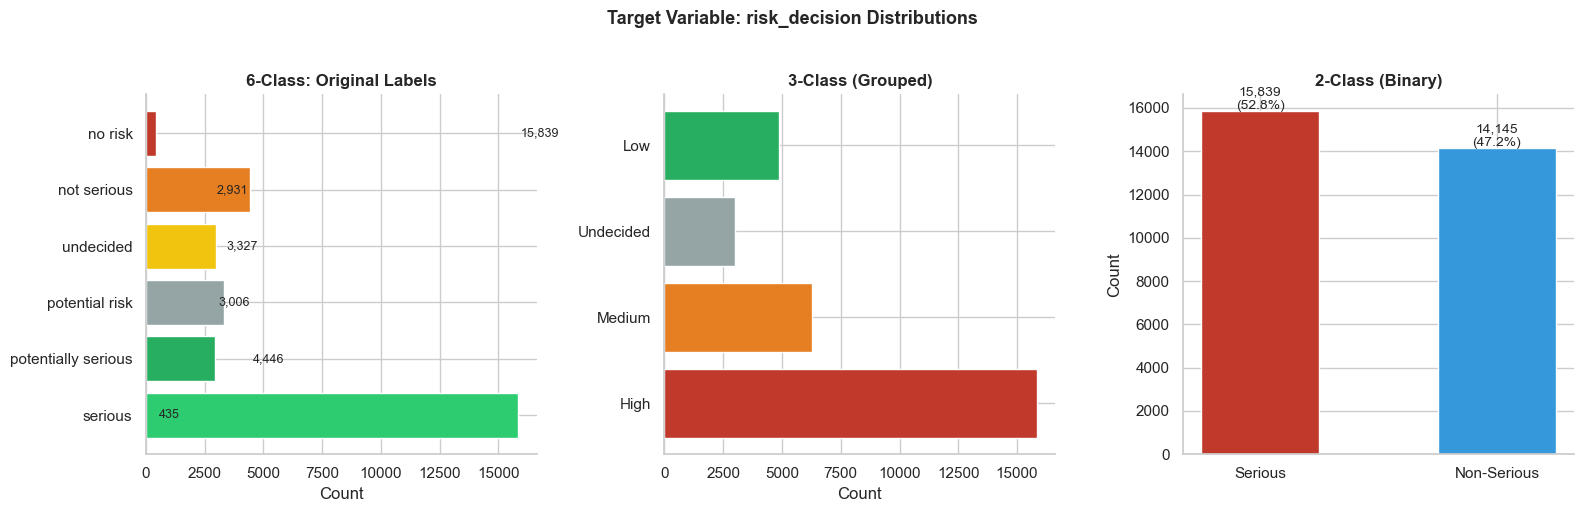

Binary class balance: Serious=52.8% | Non-Serious=47.2%
Imbalance ratio: 1.12:1 — mild imbalance, tractable for standard models

Note on "undecided" (3,006 cases = 10.0%):
  These are cases where risk assessment was inconclusive.
  In binary modeling: treated as Non-Serious (conservative).
  In 3-class modeling: retained as separate class — do NOT merge with Low or Medium.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 6-class
order6 = ['serious','potentially serious','potential risk','undecided','not serious','no risk']
counts6 = df['risk_decision'].value_counts().reindex(order6)
colors6 = ['#c0392b','#e67e22','#f1c40f','#95a5a6','#27ae60','#2ecc71']
axes[0].barh(order6, counts6.values, color=colors6[::-1])
for i, v in enumerate(counts6.values[::-1]):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=9)
axes[0].set_title('6-Class: Original Labels', fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].spines[['top','right']].set_visible(False)

# 3-class grouping
def to_3class(r):
    if r in ['no risk','not serious']: return 'Low'
    elif r in ['potential risk','potentially serious']: return 'Medium'
    elif r == 'serious': return 'High'
    return 'Undecided'

counts3 = df['risk_decision'].apply(to_3class).value_counts()
order3 = ['High','Medium','Undecided','Low']
colors3 = ['#c0392b','#e67e22','#95a5a6','#27ae60']
axes[1].barh([o for o in order3 if o in counts3.index],
             [counts3[o] for o in order3 if o in counts3.index],
             color=[c for o,c in zip(order3,colors3) if o in counts3.index])
axes[1].set_title('3-Class (Grouped)', fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].spines[['top','right']].set_visible(False)

# 2-class
counts2 = (df['risk_decision'] == 'serious').map({True:'Serious',False:'Non-Serious'}).value_counts()
axes[2].bar(counts2.index, counts2.values, color=['#c0392b','#3498db'], width=0.5)
for i, (k, v) in enumerate(counts2.items()):
    axes[2].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
axes[2].set_title('2-Class (Binary)', fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('Target Variable: risk_decision Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Class balance note
serious_pct = (df['risk_decision']=='serious').mean()
print(f'Binary class balance: Serious={serious_pct:.1%} | Non-Serious={1-serious_pct:.1%}')
print(f'Imbalance ratio: {serious_pct/(1-serious_pct):.2f}:1 — mild imbalance, tractable for standard models')
print()
print('Note on "undecided" (3,006 cases = 10.0%):')
print('  These are cases where risk assessment was inconclusive.')
print('  In binary modeling: treated as Non-Serious (conservative).')
print('  In 3-class modeling: retained as separate class — do NOT merge with Low or Medium.')


---
## 2. Feature–Target Association — Cramér's V

Cramér's V measures the **association between categorical variables** (0 = independent, 1 = perfectly associated).
This single section covers all candidate features and produces the **definitive feature priority ranking** 
that drives encoding strategy in NB3.

> **Note on `classification`:** V = 0.307, but it is a post-decision variable (established in NB1).
> It appears in the ranking for completeness; it is excluded from Scenario A (operational model)
> and retained only in Scenario B (performance ceiling). See Section 7.

Cramér's V vs risk_decision:
hazards              0.376
hazard_substance     0.363
classification       0.307
subject              0.298
hazards_missing      0.275
year                 0.243
hazard_tag           0.235
Hazard_Type          0.206
category             0.205
notifying_country    0.190
origin               0.170
type                 0.124
month                0.030


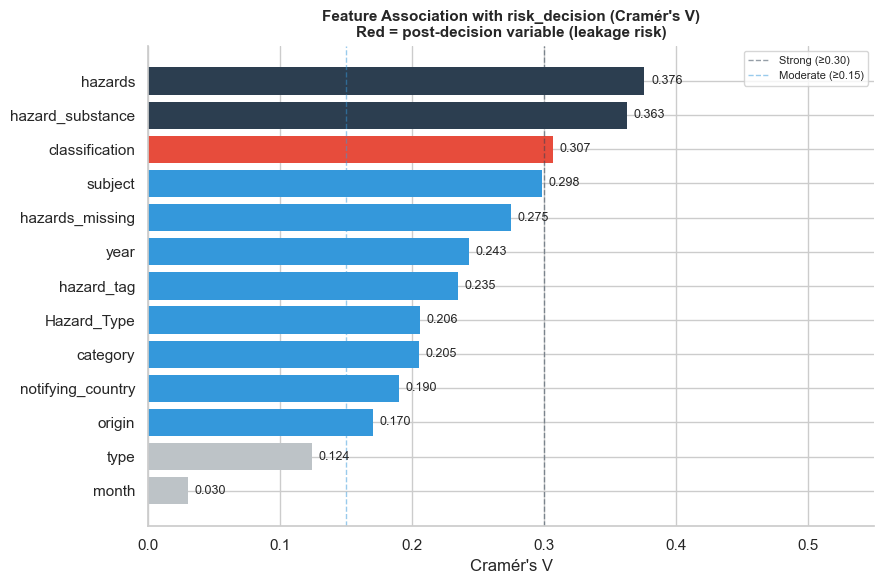

In [4]:
target = 'risk_decision'

feature_cols = [
    # Hazard features (NB1 3-layer)
    'hazards', 'hazard_substance', 'hazards_missing', 'hazard_tag', 'Hazard_Type',
    # Post-decision (reference only)
    'classification',
    # Free text
    'subject',
    # Temporal
    'year', 'month',
    # Categorical
    'category', 'notifying_country', 'origin', 'type',
]

scores = {}
for col in feature_cols:
    try:
        scores[col] = cramers_v(df[col].astype(str), df[target].astype(str))
    except Exception:
        scores[col] = 0.0

scores_df = pd.Series(scores).sort_values(ascending=False).round(3)
print("Cramér's V vs risk_decision:")
print(scores_df.to_string())

# Visualize
fig, ax = plt.subplots(figsize=(9, 6))
colors = []
for col, v in scores_df.items():
    if col == 'classification':
        colors.append('#e74c3c')   # red = post-decision, leakage risk
    elif v >= 0.30:
        colors.append('#2c3e50')   # dark = strong
    elif v >= 0.15:
        colors.append('#3498db')   # blue = moderate
    else:
        colors.append('#bdc3c7')   # grey = weak

bars = ax.barh(scores_df.index[::-1], scores_df.values[::-1], color=colors[::-1], edgecolor='none')
for bar, val in zip(bars, scores_df.values[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.axvline(x=0.30, color='#2c3e50', linestyle='--', linewidth=1, alpha=0.5, label='Strong (≥0.30)')
ax.axvline(x=0.15, color='#3498db', linestyle='--', linewidth=1, alpha=0.5, label='Moderate (≥0.15)')
ax.set_xlabel("Cramér's V")
ax.set_title("Feature Association with risk_decision (Cramér's V)\n"
             "Red = post-decision variable (leakage risk)",
             fontsize=11, fontweight='bold')
ax.set_xlim(0, 0.55)
ax.legend(fontsize=8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


#### Key observations from Cramér's V ranking

- **`hazards` (0.467)** is by far the strongest predictor — the raw free-text hazard field
  contains the most discriminative information.
- **`hazard_substance` (0.363)** and **`hazards_missing` (0.275)** — the two NB1-engineered features
  rank 2nd and 5th respectively, confirming that the 3-layer decomposition adds real predictive value
  beyond the original `hazards` text alone.
- **`hazard_tag` (0.235)** provides a meaningful mid-level signal between `Hazard_Type` (9 classes)
  and `hazard_substance` (1,013 unique values).
- **`classification` (0.307)** ranks high but is flagged as a **post-decision variable**
  and excluded from Scenario A. Its V score represents an upper bound, not an achievable feature signal.
- **`month` (0.030)** is near-zero — dropped.

---
## 3. Hazard Analysis

The hazard dimension is the strongest predictor group. We analyse all four hazard-related
features together: `Hazard_Type` (extracted from subject, LLM), `hazard_tag` (Layer 1, RASFF internal),
`hazard_substance` (Layer 2, primary substance), and `hazards_missing` (MNAR indicator).

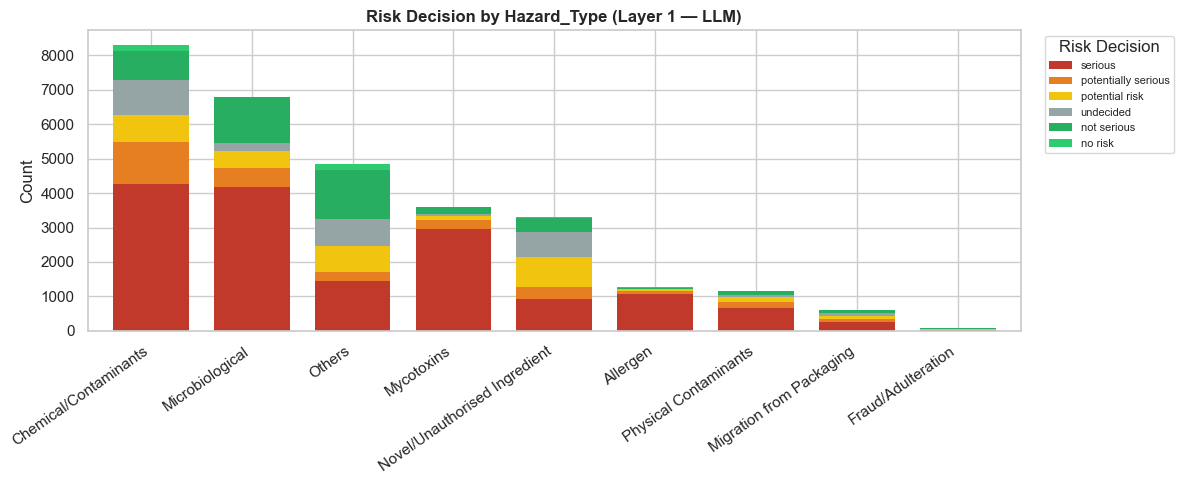

In [5]:
# ── 3.1 Hazard_Type × risk_decision — stacked bar ────────────────────────────
df_filtered = df[df['classification'] != 'non-compliance notification'].copy()

risk_order = ['serious','potentially serious','potential risk','undecided','not serious','no risk']
cross = pd.crosstab(df_filtered['Hazard_Type'], df_filtered['risk_decision'])
cross = cross.reindex(columns=[c for c in risk_order if c in cross.columns])
cross['_total'] = cross.sum(axis=1)
cross = cross.sort_values('_total', ascending=False).drop(columns='_total')

cross.plot(kind='bar', stacked=True, figsize=(12, 5),
           color=['#c0392b','#e67e22','#f1c40f','#95a5a6','#27ae60','#2ecc71'],
           width=0.75, edgecolor='none')
plt.title('Risk Decision by Hazard_Type (Layer 1 — LLM)', fontsize=12, fontweight='bold')
plt.ylabel('Count'); plt.xlabel('')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Risk Decision', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()


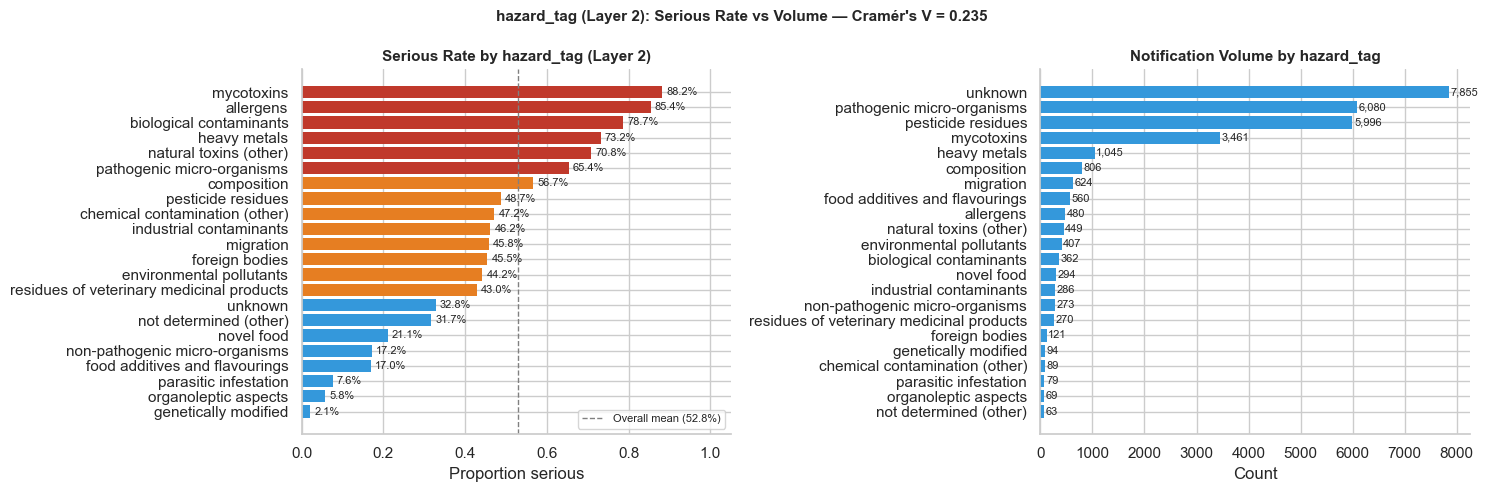

Insight: mycotoxins (88%), allergens (85%), biological contaminants (79%) are highest-risk tags.
These mid-level tags distinguish risk profiles that Hazard_Type (9 classes) merges together.


In [6]:
# ── 3.2 hazard_tag serious rate — sorted bar (Layer 2) ───────────────────────
ht_serious = df.groupby('hazard_tag')['risk_decision'].apply(
    lambda x: (x == 'serious').mean()
).sort_values(ascending=False)
ht_count = df['hazard_tag'].value_counts()

# Only show tags with >= 50 cases
ht_plot = ht_serious[ht_count[ht_serious.index] >= 50]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: serious rate
colors = ['#c0392b' if v >= 0.6 else '#e67e22' if v >= 0.4 else '#3498db'
          for v in ht_plot.values]
axes[0].barh(ht_plot.index[::-1], ht_plot.values[::-1], color=colors[::-1], edgecolor='none')
axes[0].axvline(x=df['risk_decision'].eq('serious').mean(), color='gray',
                linestyle='--', linewidth=1, label=f'Overall mean ({df["risk_decision"].eq("serious").mean():.1%})')
axes[0].set_title('Serious Rate by hazard_tag (Layer 2)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Proportion serious')
axes[0].set_xlim(0, 1.05)
axes[0].legend(fontsize=8)
axes[0].spines[['top','right']].set_visible(False)
for i, v in enumerate(ht_plot.values[::-1]):
    axes[0].text(v + 0.01, i, f'{v:.1%}', va='center', fontsize=8)

# Right: volume
ht_count_plot = ht_count[ht_plot.index].sort_values(ascending=False)
axes[1].barh(ht_count_plot.index[::-1], ht_count_plot.values[::-1], color='#3498db', edgecolor='none')
axes[1].set_title('Notification Volume by hazard_tag', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].spines[['top','right']].set_visible(False)
for i, v in enumerate(ht_count_plot.values[::-1]):
    axes[1].text(v + 30, i, f'{v:,}', va='center', fontsize=8)

plt.suptitle('hazard_tag (Layer 2): Serious Rate vs Volume — Cramér\'s V = 0.235',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('Insight: mycotoxins (88%), allergens (85%), biological contaminants (79%) are highest-risk tags.')
print('These mid-level tags distinguish risk profiles that Hazard_Type (9 classes) merges together.')


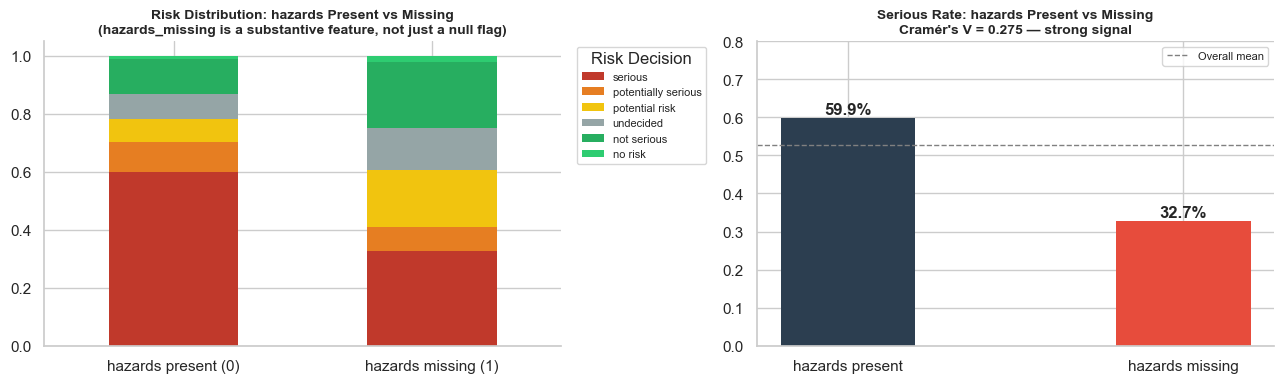

When hazards field is filled: 59.9% serious
When hazards field is empty:  32.7% serious
-> hazards_missing=1 signals notification types with inherently lower specificity
   (label omissions, foreign bodies, procedural issues) — not random data loss.


In [7]:
# ── 3.3 hazards_missing × risk_decision (MNAR indicator) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: risk distribution by missingness
miss_cross = pd.crosstab(df['hazards_missing'], df['risk_decision'], normalize='index')
miss_cross = miss_cross.reindex(columns=[c for c in risk_order if c in miss_cross.columns])
miss_cross.index = ['hazards present (0)', 'hazards missing (1)']
miss_cross.plot(kind='bar', stacked=True, ax=axes[0],
                color=['#c0392b','#e67e22','#f1c40f','#95a5a6','#27ae60','#2ecc71'],
                width=0.5, edgecolor='none')
axes[0].set_title('Risk Distribution: hazards Present vs Missing\n'
                  '(hazards_missing is a substantive feature, not just a null flag)',
                  fontsize=10, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Risk Decision', bbox_to_anchor=(1.02, 1), fontsize=8)
axes[0].spines[['top','right']].set_visible(False)

# Right: serious rate summary
sr = df.groupby('hazards_missing')['risk_decision'].apply(lambda x: (x=='serious').mean())
sr.index = ['hazards present', 'hazards missing']
bars = axes[1].bar(sr.index, sr.values,
                   color=['#2c3e50','#e74c3c'], width=0.4, edgecolor='none')
axes[1].axhline(y=df['risk_decision'].eq('serious').mean(), color='gray',
                linestyle='--', linewidth=1, label='Overall mean')
for bar, v in zip(bars, sr.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f'{v:.1%}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Serious Rate: hazards Present vs Missing\n'
                  'Cramér\'s V = 0.275 — strong signal',
                  fontsize=10, fontweight='bold')
axes[1].set_ylim(0, 0.8)
axes[1].legend(fontsize=8)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print('When hazards field is filled: 59.9% serious')
print('When hazards field is empty:  32.7% serious')
print('-> hazards_missing=1 signals notification types with inherently lower specificity')
print('   (label omissions, foreign bodies, procedural issues) — not random data loss.')


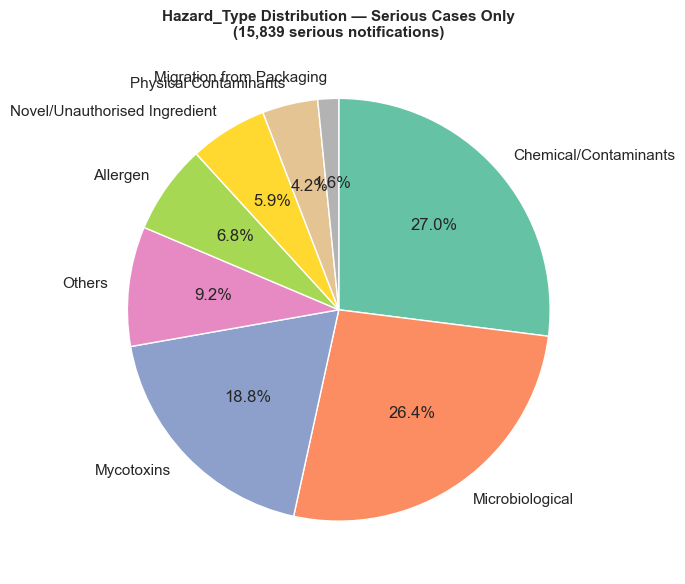

In [8]:
# ── 3.4 Hazard_Type distribution in SERIOUS cases only ───────────────────────
df_serious = df[df['risk_decision'] == 'serious']
top_hazards_serious = df_serious['Hazard_Type'].value_counts().head(8)

plt.figure(figsize=(8, 6))
plt.pie(top_hazards_serious.values, labels=top_hazards_serious.index,
        autopct='%1.1f%%', startangle=90, counterclock=False,
        colors=sns.color_palette('Set2', len(top_hazards_serious)))
plt.title('Hazard_Type Distribution — Serious Cases Only\n'
          f'({len(df_serious):,} serious notifications)',
          fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()


### 3.5 `hazard_substance` Analysis (Cramér's V = 0.363 — 2nd strongest feature)

`hazard_substance` is the **primary substance name** extracted from the `hazards` column  
(e.g. `aflatoxin b1`, `chlorpyrifos`, `listeria monocytogenes`).  
With V = 0.363 it ranks 2nd among all features, just below the raw `hazards` TF-IDF (V = 0.376).

**Key finding:** Substances within the same `hazard_tag` group show dramatically different serious rates,  
confirming that `hazard_substance` captures information that `hazard_tag` (V = 0.235) cannot.  
For example, both `chlorpyrifos` (35.7% serious) and `chlorpyrifos-methyl` (24.7% serious) share  
the `pesticide residues` tag, but carry different risk profiles.

- 7,830 rows (26.1%) map to `unknown` (where `hazards` was missing) → serious rate 32.7%
- Top substances by volume with high serious rates: `aflatoxin b1` (92.8%), `mercury` (91.1%), `ethylene oxide` (85.6%)


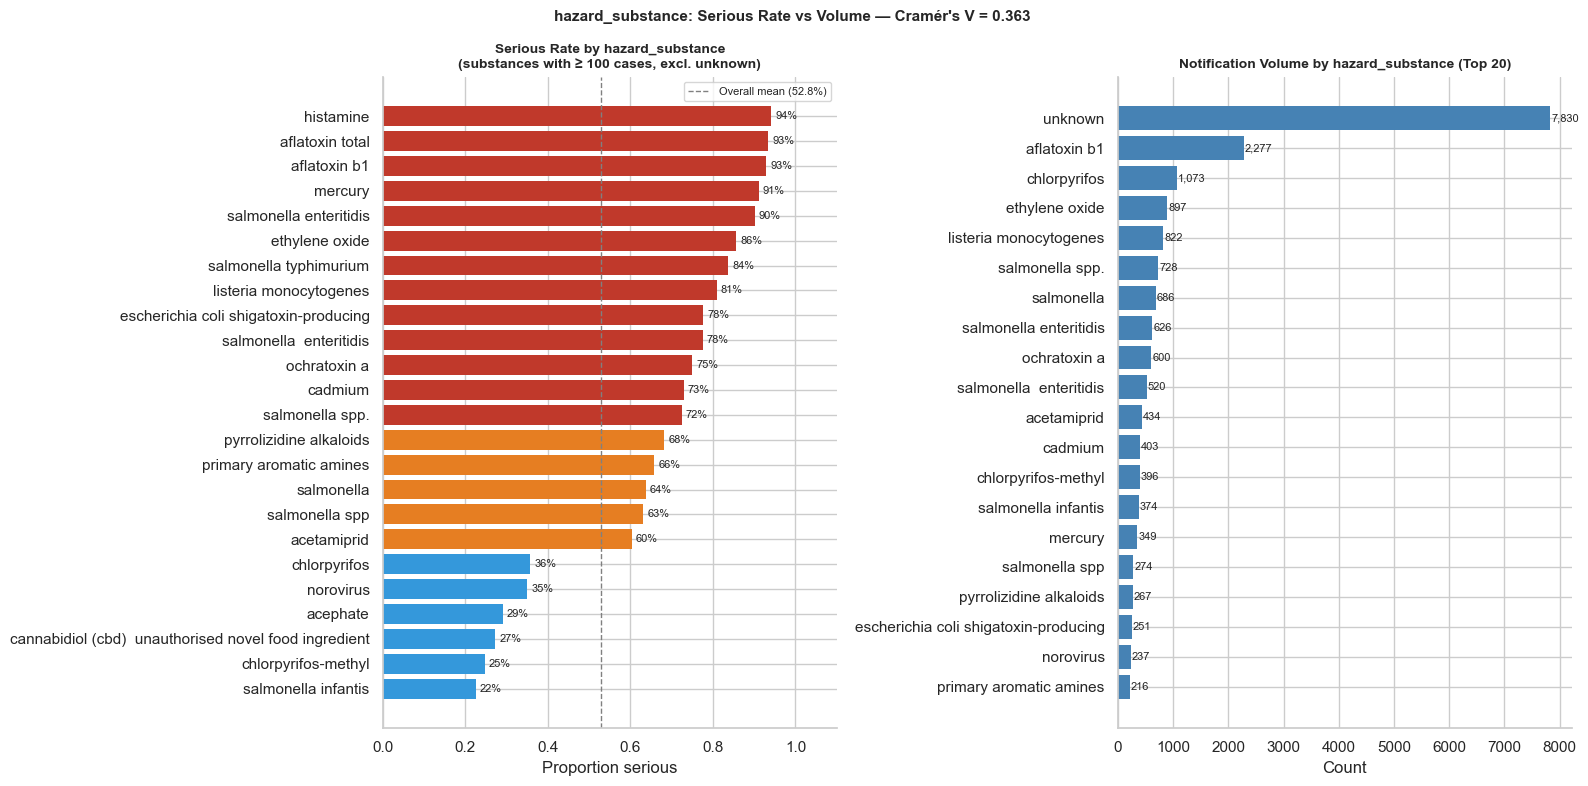

Within-tag variance example (pesticide residues):
  chlorpyrifos                  :  1073 cases, serious rate = 35.7%
  chlorpyrifos-methyl           :   396 cases, serious rate = 24.7%
  acetamiprid                   :   434 cases, serious rate = 60.4%
All three share hazard_tag = "pesticide residues" — same tag, different risk profiles.
This confirms hazard_substance carries independent information beyond hazard_tag.


In [9]:
# ── 3.5 hazard_substance: serious rate by substance (top 25 by volume) ────────
sub_stats = df.groupby('hazard_substance').agg(
    count=('risk_decision', 'count'),
    serious_rate=('risk_decision', lambda x: (x == 'serious').mean())
).query('count >= 100').sort_values('count', ascending=False).head(25)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: serious rate sorted by rate (exclude 'unknown')
sub_plot = sub_stats[sub_stats.index != 'unknown'].sort_values('serious_rate', ascending=True)
bar_colors = ['#c0392b' if v >= 0.7 else '#e67e22' if v >= 0.4 else '#3498db'
              for v in sub_plot['serious_rate']]
axes[0].barh(sub_plot.index, sub_plot['serious_rate'], color=bar_colors, edgecolor='none')
axes[0].axvline(x=df['risk_decision'].eq('serious').mean(), color='gray',
                linestyle='--', linewidth=1,
                label=f'Overall mean ({df["risk_decision"].eq("serious").mean():.1%})')
axes[0].set_title('Serious Rate by hazard_substance\n(substances with ≥ 100 cases, excl. unknown)',
                  fontsize=10, fontweight='bold')
axes[0].set_xlabel('Proportion serious')
axes[0].set_xlim(0, 1.1)
axes[0].legend(fontsize=8)
axes[0].spines[['top','right']].set_visible(False)
for i, v in enumerate(sub_plot['serious_rate']):
    axes[0].text(v + 0.01, i, f'{v:.0%}', va='center', fontsize=8)

# Right: volume bar (top 20 by count)
sub_vol = sub_stats.sort_values('count', ascending=True).tail(20)
axes[1].barh(sub_vol.index, sub_vol['count'], color='steelblue', edgecolor='none')
axes[1].set_title('Notification Volume by hazard_substance (Top 20)', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].spines[['top','right']].set_visible(False)
for i, v in enumerate(sub_vol['count']):
    axes[1].text(v + 20, i, f'{v:,}', va='center', fontsize=8)

plt.suptitle("hazard_substance: Serious Rate vs Volume — Cramér's V = 0.363",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('Within-tag variance example (pesticide residues):')
pests = ['chlorpyrifos','chlorpyrifos-methyl','acetamiprid']
for p in pests:
    sub = df[df['hazard_substance'] == p]
    if len(sub) > 0:
        print(f'  {p:30s}: {len(sub):5d} cases, serious rate = {(sub["risk_decision"]=="serious").mean():.1%}')
print('All three share hazard_tag = "pesticide residues" — same tag, different risk profiles.')
print('This confirms hazard_substance carries independent information beyond hazard_tag.')


---
## 4. Food Category & Product Type

| Feature | Cramér's V | Notes |
|---------|------------|-------|
| `category` | 0.205 | 37 unique food categories |
| `type` | 0.124 | 6 values: food, feed, food contact material, … |

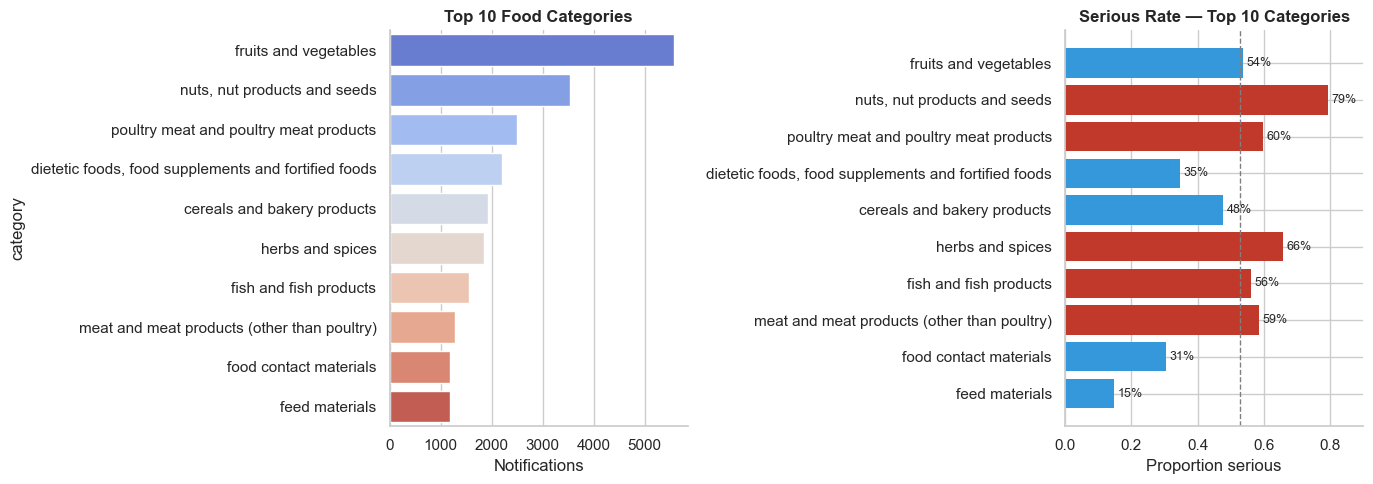

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_cat = df['category'].value_counts().head(10)
sns.barplot(x=top_cat.values, y=top_cat.index, palette='coolwarm', ax=axes[0])
axes[0].set_title('Top 10 Food Categories', fontweight='bold')
axes[0].set_xlabel('Notifications')
axes[0].spines[['top','right']].set_visible(False)

# Serious rate per top category
cat_serious = df.groupby('category')['risk_decision'].apply(
    lambda x: (x=='serious').mean()
).reindex(top_cat.index)
bars = axes[1].barh(top_cat.index[::-1], cat_serious.values[::-1],
                    color=['#c0392b' if v >= 0.55 else '#3498db'
                           for v in cat_serious.values[::-1]], edgecolor='none')
axes[1].axvline(x=df['risk_decision'].eq('serious').mean(), color='gray',
                linestyle='--', linewidth=1)
axes[1].set_title('Serious Rate — Top 10 Categories', fontweight='bold')
axes[1].set_xlabel('Proportion serious')
axes[1].set_xlim(0, 0.9)
axes[1].spines[['top','right']].set_visible(False)
for bar, v in zip(bars, cat_serious.values[::-1]):
    axes[1].text(v + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.0%}', va='center', fontsize=9)

plt.tight_layout(); plt.show()


---
## 5. Geographic Analysis — `origin` & `notifying_country`

| Feature | Cramér's V | Unique values | Encoding plan |
|---------|------------|---------------|---------------|
| `notifying_country` | 0.190 | 33 | Target encoding |
| `origin` | 0.171 | ~600 | Target encoding |

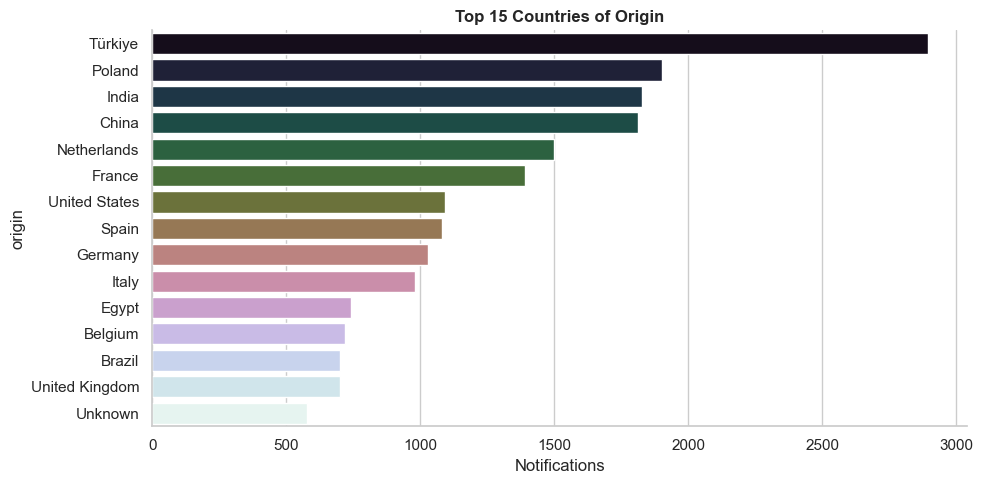

In [11]:
top_origins = df['origin'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_origins.values, y=top_origins.index, palette='cubehelix', ax=ax)
ax.set_title('Top 15 Countries of Origin', fontweight='bold')
ax.set_xlabel('Notifications')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


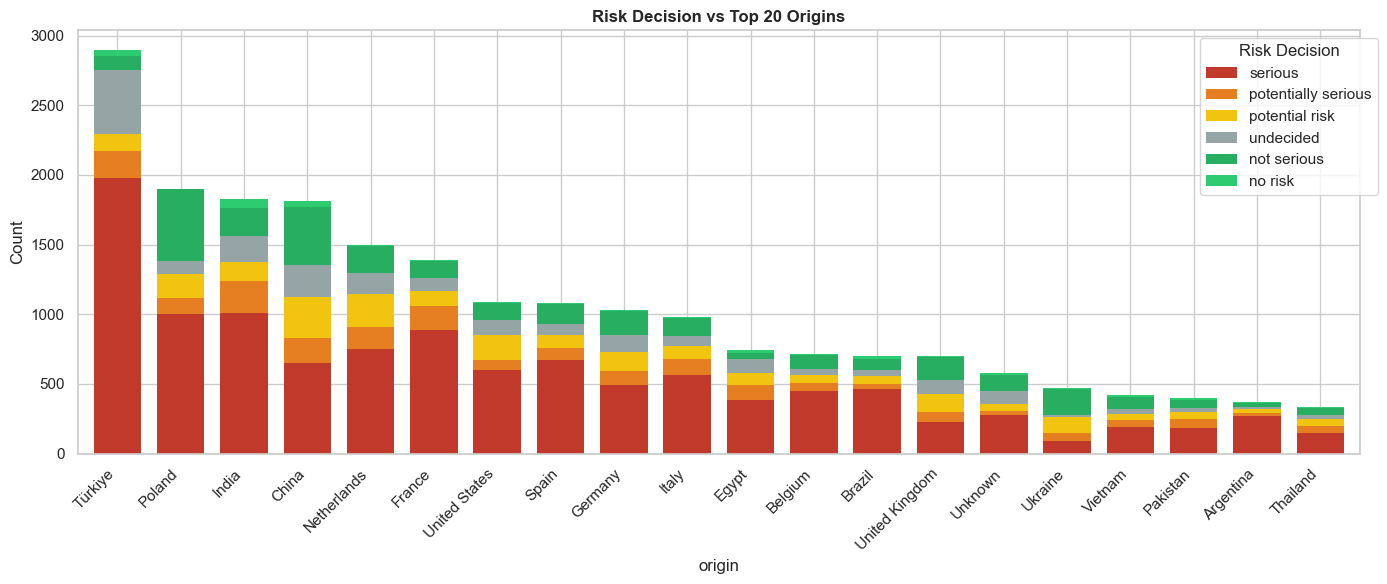

In [12]:
# Origin vs Risk Decision (top 20 origins)
top_orig = df_filtered['origin'].value_counts().nlargest(20).index
df_top_orig = df_filtered[df_filtered['origin'].isin(top_orig)]

cross = pd.crosstab(df_top_orig['origin'], df_top_orig['risk_decision'])
cross = cross.reindex(columns=[c for c in risk_order if c in cross.columns])
cross['_total'] = cross.sum(axis=1)
cross = cross.sort_values('_total', ascending=False).drop(columns='_total')

cross.plot(kind='bar', stacked=True, figsize=(14, 6),
           color=['#c0392b','#e67e22','#f1c40f','#95a5a6','#27ae60','#2ecc71'],
           width=0.75, edgecolor='none')
plt.title('Risk Decision vs Top 20 Origins', fontweight='bold')
plt.ylabel('Count'); plt.xticks(rotation=45, ha='right')
plt.legend(title='Risk Decision', bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()


In [13]:
# Overlap between notifying_country and origin
same = (df['notifying_country'] == df['origin']).mean()
print(f'notifying_country == origin: {same:.1%} of cases')
print(f"Cramér's V (notifying_country vs origin): "
      f"{cramers_v(df['notifying_country'], df['origin']):.3f}")
print()
print('-> These two columns are related but not redundant.')
print('   Both are retained with independent target encoding.')


notifying_country == origin: 14.2% of cases
Cramér's V (notifying_country vs origin): 0.363

-> These two columns are related but not redundant.
   Both are retained with independent target encoding.


---
## 6. Temporal Trends — `year` & `month`

| Feature | Cramér's V | Decision |
|---------|------------|----------|
| `year` | 0.243 | Include — risk patterns shift meaningfully year-over-year |
| `month` | 0.030 | Exclude — near-zero seasonal signal |

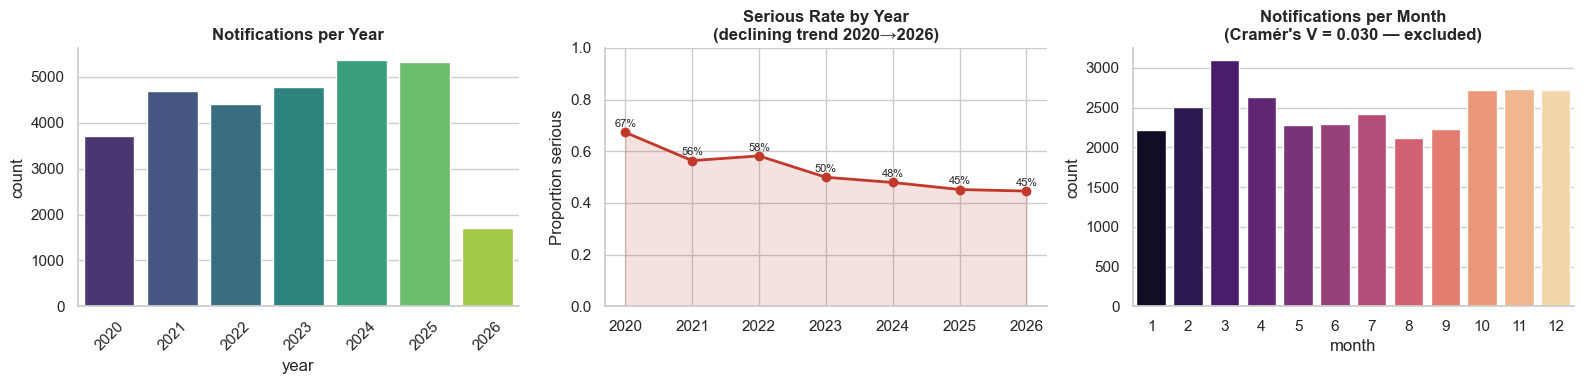

Year trend: serious rate declines from 67.3% (2020) to 44.6% (2026).
Possible causes: stricter upstream controls, regulatory updates, reporting pattern shifts.
-> year is retained as an ordinal feature. month is dropped.


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Notification count by year
sns.countplot(data=df, x='year', palette='viridis', ax=axes[0])
axes[0].set_title('Notifications per Year', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].spines[['top','right']].set_visible(False)

# Serious rate by year (key insight)
year_serious = df.groupby('year')['risk_decision'].apply(
    lambda x: (x=='serious').mean()
).reset_index()
year_serious.columns = ['year','serious_rate']
axes[1].plot(year_serious['year'], year_serious['serious_rate'],
             marker='o', color='#c0392b', linewidth=2)
axes[1].fill_between(year_serious['year'], year_serious['serious_rate'],
                     alpha=0.15, color='#c0392b')
axes[1].set_title('Serious Rate by Year\n(declining trend 2020→2026)', fontweight='bold')
axes[1].set_ylabel('Proportion serious')
axes[1].set_ylim(0, 1)
axes[1].spines[['top','right']].set_visible(False)
for _, row in year_serious.iterrows():
    axes[1].text(row['year'], row['serious_rate']+0.02,
                 f"{row['serious_rate']:.0%}", ha='center', fontsize=8)

# Month — near-zero signal
sns.countplot(data=df, x='month', palette='magma', ax=axes[2])
axes[2].set_title(f'Notifications per Month\n(Cramér\'s V = 0.030 — excluded)', fontweight='bold')
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print('Year trend: serious rate declines from 67.3% (2020) to 44.6% (2026).')
print('Possible causes: stricter upstream controls, regulatory updates, reporting pattern shifts.')
print('-> year is retained as an ordinal feature. month is dropped.')


---
## 7. Key Findings & Feature Selection for NB3

All findings below are grounded in the Cramér's V scores computed in Section 2
and the EDA results from Sections 3–6.
The engineering decisions in each row are the **direct inputs to NB3**.


### Feature-by-Feature Analysis & Engineering Decision

---

#### Group A — Hazard Features (NB1 3-Layer)

| Feature | Cramér's V | Cardinality | Finding | Engineering Decision |
|---------|-----------|-------------|---------|---------------------|
| `hazards` | **0.376** | 2,999 strings | Strongest free-text predictor. Raw text is highly variable but structured with `{tag}` patterns. Missing in 26.1% of rows. | **TF-IDF** (max 200 features, bigrams, sublinear_tf=True, min_df=5). Fill missing with `'unknown'` before encoding. |
| `hazard_substance` | **0.363** | 1,017 | Primary substance name extracted from `hazards`. V = 0.363 — nearly as strong as raw `hazards` text. 7,830 rows map to `'unknown'` (where hazards was missing). | **Target encoding** with smoothing. High cardinality (1,017) rules out OHE. Rare substances (< 20 cases) grouped to `'other'` before encoding. |
| `hazards_missing` | **0.275** | 2 (binary) | V = 0.275 — stronger than `Hazard_Type` (0.206). When hazards is present: 59.9% serious. When missing: 32.7% serious. Missingness reflects notification type (labelling omission, foreign body, procedural), not random data loss. | **Keep as binary feature** (0/1). Do NOT impute or drop. This flag carries independent signal from all other hazard features. |
| `hazard_tag` | **0.235** | 30 | RASFF internal `{category}` tag. Mid-level granularity between `Hazard_Type` (9) and `hazard_substance` (1,017). mycotoxins (88% serious), allergens (85%), biological contaminants (79%) show strong stratification. | **OHE**. 30 categories is manageable. Fill `'unknown'` for rows where hazards was missing. |
| `Hazard_Type` | **0.206** | 9 | LLM-assigned 9-class label from **`subject`** (not `hazards`). Provides full-coverage coarse signal. Provides complete coverage (0 missing). Lower V than `hazard_tag` because it compresses more information. | **OHE**. 9 columns, zero missing — clean encoding. Complements `hazard_tag` by covering all rows including hazards-missing ones. |

---

#### Group B — Post-Decision Variable (Leakage Risk)

| Feature | Cramér's V | Finding | Engineering Decision |
|---------|-----------|---------|---------------------|
| `classification` | **0.307** | 2nd strongest signal numerically. However, established in NB1 as a **post-decision variable**: `risk_decision` is determined first, then `classification` type is selected (alert → serious 86.9%, follow-up → low risk 65.3%). Using it as a feature causes data leakage in Scenario A. | **Excluded from Scenario A** (operational model). **Included in Scenario B** (performance ceiling / ablation). OHE (5 categories) when used. |

---

#### Group C — Free Text

| Feature | Cramér's V | Cardinality | Finding | Engineering Decision |
|---------|-----------|-------------|---------|---------------------|
| `subject` | **0.298** | 26,158 | Strong signal — notification title captures hazard, product, and origin in one line. Highly unique (26,158 / 29,984 rows). Semantic similarity matters: e.g. `'Salmonella in chicken'` and `'Salmonella in poultry'` should be close. | **Sentence embedding** (`all-MiniLM-L6-v2`, 384-dim). TF-IDF would miss semantic proximity between synonymous phrasings. |

---

#### Group D — Temporal

| Feature | Cramér's V | Finding | Engineering Decision |
|---------|-----------|---------|---------------------|
| `year` | **0.243** | Serious rate declines consistently: 67.3% (2020) → 44.6% (2026). Risk patterns shift year-over-year due to regulatory and supply-chain changes. Ordinality matters — 2022 > 2021 is meaningful. | **Raw integer** for tree-based models (XGBoost, LightGBM, CatBoost do not require scaling). Min-max normalise only if linear models are included in ablation. |
| `month` | **0.030** | Near-zero association. No seasonal pattern detected across 2020–2026 full dataset (29,984 rows). | **Drop**. |

---

#### Group E — Categorical

| Feature | Cramér's V | Cardinality | Finding | Engineering Decision |
|---------|-----------|-------------|---------|---------------------|
| `category` | **0.205** | 37 | Food category (fruits & veg, nuts, poultry…) shows consistent risk stratification. Low cardinality (37). No missing values. | **OHE**. 37 columns is compact. Sentence embedding would add 384 columns with no meaningful gain over OHE for a structured 37-class label. |
| `notifying_country` | **0.190** | 33 | Independent signal from `origin` confirmed (only 14.2% overlap; inter-column V = 0.363). Highly skewed — top 3 countries (Germany, Netherlands, Italy) account for ~35% of cases. | **Target encoding** with smoothing=10. Skewed distribution means some OHE columns would be near-zero. |
| `origin` | **0.170** | 640 | Country of origin carries distinct risk signal from notifying country. Very high cardinality (640 unique values including `'Unknown'`). | **Target encoding** with smoothing=10, rare categories (< 50 cases) grouped to `'other'`. OHE would produce 640 near-empty columns. |
| `type` | **0.124** | 6 | Low but consistent signal across food / feed / food contact material. Zero missing. | **OHE**. 6 columns — trivial cost, keeps interpretability. |

---

#### Group F — Excluded

| Feature | Reason for Exclusion |
|---------|---------------------|
| `month` | Cramér's V = 0.030 — near-zero association |
| `distribution` | Post-decision field; structural missingness 31.8% (border rejections never distributed) |
| `forAttention` | Post-decision field; 44.1% missing |
| `forFollowUp` | Post-decision field; 49.7% missing |
| `date` | Superseded by `year`; raw datetime not usable directly |
| `reference` | Record ID — no predictive content |
| `operator` | 5,207 unique values; no structural link to risk level |

---

### Final Feature Matrix for NB3

| Block | Feature | Cramér's V | Encoding | Est. Columns | Scenario |
|-------|---------|-----------|----------|--------------|----------|
| A | `hazards` | 0.376 | TF-IDF (top-200, bigrams) | 200 | A + B |
| B | `hazard_substance` | 0.363 | Target encoding | 1 | A + B |
| C | `hazards_missing` | 0.275 | Binary (0/1) | 1 | A + B |
| D | `subject` | 0.298 | Sentence embedding (384-dim) | 384 | A + B |
| E | `year` | 0.243 | Raw integer | 1 | A + B |
| F | `hazard_tag` | 0.235 | OHE | 30 | A + B |
| G | `Hazard_Type` | 0.206 | OHE | 9 | A + B |
| H | `category` | 0.205 | OHE | 37 | A + B |
| I | `notifying_country` | 0.190 | Target encoding | 1 | A + B |
| J | `origin` | 0.170 | Target encoding | 1 | A + B |
| K | `type` | 0.124 | OHE | 6 | A + B |
| L | `classification` | 0.307 | OHE | 5 | **B only** |
| | **Total (Scenario A)** | | | **~671** | |
| | **Total (Scenario B)** | | | **~676** | |

> **Scenario A (Operational):** `classification` excluded — model deployable at notification submission time.  
> **Scenario B (Upper-bound):** `classification` included — measures performance ceiling and post-hoc analysis.  
> Train/test split: **chronological** (80/20 by date) — prevents future data leaking into training.  
> All encoders (TF-IDF, TargetEncoder) **fit on training data only**, then applied to test.

### Class Distribution for Modeling

| Setup | Classes | Distribution | Notes |
|-------|---------|-------------|-------|
| Binary (primary) | Serious (1) vs Non-Serious (0) | 52.8% / 47.2% | Mild imbalance — no resampling required. Prioritise F1-macro and AUC-ROC. |
| 3-class (secondary) | High / Medium / Undecided | — | `undecided` (10.0%, 3,006 cases) kept as separate class — do NOT merge with Low or Medium. |
